# Web scrapper - Raspado del archivo html de buscador de proyectos con la palabra "Muerte sùbita"

## Proyectos
Se denominan proyectos a las iniciativas legislativas de los Diputados ,Senadores y Poder Ejecutivo. Hay distintos tipos de proyectos:

* Proyectos de ley: destinados a crear, modificar, sustituir o abrogar una ley, institución o norma de caracter general.

* Proyectos de resolución: destinados a la adopción de medidas relativas a la composición u organización interna del cuerpo, las modificaciones del reglamento y, en general, de toda disposición de carácter imperativo que pueda adoptar la Cámara.

* Proyectos de declaración: destinados a expresar una opinión del cuerpo sobre cualquier hecho de carácter público o privado, o manifestar la voluntad de que el Poder Ejecutivo practique algún acto en particular.

### Sitio web : Buscador de proyecto
Link: https://www.diputados.gov.ar/proyectos/

### Para raspar de 'resultado'
Link: https://www.diputados.gov.ar/proyectos/resultado.html

div class cms_container-row 
* section class resultados-proyectos
* h3 class resultados-title = Resultados de Búsqueda: 262281 Proyectos Encontrados -- > cantidad de proyectos
* nav aria-label "Page navigation" / span = Página 1 de 13115 -- pagina a rastrear
* div
    * h4 : PROYECTO DE RESOLUCIÓN
    * div class dp-metadata / span
    * div class dp-texto
    * div class detalle-proyecto
        * h5 firmante
        * table class table table-striped table-hover
            * thead tr th FIRMANTE DISTRITO BLOQUE
            * Tbody tr td
    * div class detalle-proyecto
        * h5 Giro a comisiones de diputados ...
    * div class detalle-proyecto
        * h5 TRAMITE ...
    * div d-flex justify-content-center gap-1 para ver pdf : https://www.senado.gob.ar/parlamentario/comisiones/verExp/1058.24/S/PD

En esta notebook, trabajaremos con el archivo html resultado de inspeccionar el còdigo de la pàgina resultado que se carga del buscador de proyecto por la palabra de "Muerte sùbita". Este raspado serà ùtil cuando se haga el web scraping.
 

In [1]:
#! /usr/bin/env python3.6
import argparse
import requests
import datetime
from bs4 import BeautifulSoup
import json

import pandas as pd
import pickle
import numpy as np
import time
import random

#----------------------------
import re
import urllib.request


In [2]:
# Si se realizarà web scrapping este ejemplo de sitio deberìa rasparser https://www.diputados.gov.ar/proyectos/resultado.html
html_file_path = '/media/sf_iamas_datos2024/proyectos_parlamentarios/sitio_prueba.html'

In [3]:
# Esto es lo que ser cargarìa si se hiciera el web scraping. Que por ahora es de un archivo html
with open(html_file_path, 'r') as f:
    # Parse HTML using BeautifulSoup
    soup = BeautifulSoup(f) # 'html.parser'

In [4]:
soup


<!DOCTYPE html>

<html lang="es">
<head>
<meta charset="utf-8"/>
<meta content="IE=edge" http-equiv="X-UA-Compatible"/>
<meta content="width=device-width, initial-scale=1" name="viewport"/>
<title>Resultado</title>
<meta content="" name="description">
<meta content="" name="keywords">
<meta content="index, follow" name="robots">
<meta content="7 days" name="revisit-after"/>
<link href="/export/system/modules/ar.gob.hcdn.base/resources/img/apple-touch-icon.png" rel="apple-touch-icon" sizes="180x180"/>
<link href="/export/system/modules/ar.gob.hcdn.base/resources/img/favicon-32x32.png" rel="icon" sizes="32x32" type="image/png"/>
<link href="/export/system/modules/ar.gob.hcdn.base/resources/img/favicon-16x16.png" rel="icon" sizes="16x16" type="image/png"/>
<link href="/system/modules/ar.gob.hcdn.base/resources/img/favicon.ico" rel="icon" sizes="16x16" type="image/png"/>
<link href="/export/system/modules/ar.gob.hcdn.base/resources/vendor/css/roboto.min.css" rel="stylesheet" type="text/cs

In [5]:
# div class cms_container-row // section class="resultados-proyectos"-- contiene la lista de 72 proyectos
section_divs = soup.find('div', attrs={'class': 'cms_container-row'}).find('section', attrs={'class': 'resultados-proyectos'})
# 'Resultados de Búsqueda: 72 Proyectos Encontrados' . Extraer el nùmero nos va a ayudar a buscar por pàgina . Para seleccionar por pàgina ver nav 'Page navigation"
proy_num = section_divs.find('h3', attrs={'class': 'resultados-title'}).text
proy_num = int(re.findall(r'\d+', proy_num)[0])

In [6]:
proy_num

72

In [7]:
# para extraer datos de metadatos del proyecto
def get_metadata_proy(containers):
    data = {}
    for container in containers:
        key_values = container.text.split(':')
        if len(key_values)==2:
            data[key_values[0].strip().lower()] = key_values[1].strip().lower()
               
    return data

# para extraer las tablas de detalle de proyecto
def get_table_list(containers):
    result_list = []
    table = containers.find('table')
    thead = table.thead.find_all('th')
    tr = [tr.find_all('td')  for tr in table.tbody.find_all('tr')]
    for row in tr :
        result = {}
        for header, value in zip(thead,row):
            result[header.text.strip().lower()] = value.text.strip().lower()
        result_list.append(result)
    return result_list

#### Ejemplos de raspado web para recolectar datos de un proyecto

In [8]:
# proyecto 0
proyecto_i = section_divs.find('div').find_all('div')[0]

In [9]:
proyecto_i

<div>
<h4>PROYECTO DE LEY</h4>
<div class="dp-metadata">
<span><strong>Iniciado en: </strong>Diputados</span>
<span><strong>Expediente Diputados: </strong>0387-D-2024</span>
<br/>
<span><strong>Publicado en: </strong>Trámite Parlamentario N° 9</span>
<span><strong>Fecha: </strong>07/03/2024</span>
<br/>
</div>
<div class="dp-texto">PROMOCION Y CAPACITACION EN LAS TECNICAS DE REANIMACION CARDIOPULMONAR BASICAS (RCP) - LEY 26835 -. MODIFICACIONES SOBRE AMPLIACION DE LA SEGURIDAD EN LA ACTIVIDAD EDUCATIVA Y DEPORTIVA. MODIFICACION DE LA LEY 27159, DE MUERTE SUBITA </div>
<div class="detalle-proyecto">
<h5>FIRMANTES</h5>
<table class="table table-striped table-hover">
<thead>
<tr>
<th>FIRMANTE</th>
<th>DISTRITO</th>
<th>BLOQUE</th>
</tr>
</thead>
<tbody>
<tr>
<td>CARRIZO, SOLEDAD</td>
<td>CORDOBA</td>
<td>UCR - UNIÓN CÍVICA RADICAL</td>
</tr>
</tbody>
</table>
</div>
<div class="detalle-proyecto">
<h5>GIRO A COMISIONES EN DIPUTADOS</h5>
<table class="table table-striped table-hover">
<thea

In [10]:
# ######################################## BASE DE PROYECTO ########################################
# <h4>PROYECTO DE LEY</h4>
tipo_proy = proyecto_i.find('h4').text.lower()
# <div class="dp-metadata">
metadata_proy = proyecto_i.find('div',{'class':'dp-metadata'})
metadata_proy_dic = get_metadata_proy(metadata_proy.find_all('span'))
# <div class="dp-texto">
texto_proy = proyecto_i.find('div',{'class':'dp-texto'}).text.lower()

In [11]:
metadata_proy_dic 

{'iniciado en': 'diputados',
 'expediente diputados': '0387-d-2024',
 'publicado en': 'trámite parlamentario n° 9',
 'fecha': '07/03/2024'}

In [12]:
# ######################################## DETALLES DE PROYECTO ########################################
#proyecto_i.find_all('div',{'class':'detalle-proyecto'})
detalles_proy = {}
detalles_list = proyecto_i.find_all('div',{'class':'detalle-proyecto'})
for detalle_i in detalles_list:
    key = detalle_i.h5.text.lower()
    detalles_proy[key] = get_table_list(detalle_i)


In [13]:
detalles_proy

{'firmantes': [{'firmante': 'carrizo, soledad',
   'distrito': 'cordoba',
   'bloque': 'ucr - unión cívica radical'}],
 'giro a comisiones en diputados': [{'comisión': 'accion social y salud publica'},
  {'comisión': 'educacion'},
  {'comisión': 'deportes'},
  {'comisión': 'presupuesto y hacienda'}]}

In [14]:
# ######################################## TEXTOS DEL PROYECTO ########################################
# Acceder a textos de proyecto :"Sumario" y links a pdfs de 'Ver documento original'. 'Texto completo del proyecto Senado' (otro sitio con pdf 
# 'Texto completo del proyecto Senado'  te lleva a otro sitio que te permite bajar pdf desde Autores, Trámite Legislativo, Texto Definitivo, Texto Original
# div class="d-flex justify-content-center gap-1"
textos_sumario_links = {}
textos_sumario_links['expediente diputados'] = metadata_proy_dic['expediente diputados']
accesos = proyecto_i.find('div',{'class':'d-flex justify-content-center gap-1'})
# sumario
sumario_id = accesos.button.get('data-target').replace('#','')
textos_sumario_links['sumario'] = {}
textos_sumario_links['sumario']['id'] = sumario_id
textos_sumario_links['sumario']['texto'] = proyecto_i.find('div',{'id':sumario_id}).text.lower()

# links
for a in accesos.find_all('a'):
    a = accesos.a
    key = a.text.replace('Ver','href')
    textos_sumario_links[key.strip()] = a.get('href')


In [15]:
  #identificar los listados de proyectos del buscador
section_divs = soup.find('div', attrs={'class': 'cms_container-row'}).find('section', attrs={'class': 'resultados-proyectos'})
    #primer div que contiene el conjunto de div
proy_section = section_divs.find('div')


In [16]:
len(section_divs.find('div').find_all('div'))

503

72 proyectos. Guardar cada proyecto como archivo json.

In [17]:
def parsing_data(soup):
    result = []
    
    #identificar le listado de proyectos del buscador
    section_divs = soup.find('div', attrs={'class': 'cms_container-row'}).find('section', attrs={'class': 'resultados-proyectos'})
    #primer div que contiene el conjunto de div
    proy_section = section_divs.find('div')
    #cada div representa un proyecto
    
    i = 0
    for proyecto_i in proy_section.find_all('div'):

        proy_result = {}
        
        try:
            ######################################### BASE DE PROYECTO ########################################

            metadata_proyecto = proyecto_i.find('div',{'class':'dp-metadata'})
        
            if not( metadata_proyecto is None):
                
                # <h4>PROYECTO DE LEY</h4>
                tipo_proy = proyecto_i.find('h4')
                tipo_proy = tipo_proy.text.lower()
                proy_result['tipo de proyecto'] = tipo_proy
               
                # <div class="dp-metadata"> 
                proy_result['metadata'] = get_metadata_proy(metadata_proyecto.find_all('span'))
               
                # <div class="dp-texto">
                texto_proy = proyecto_i.find('div',{'class':'dp-texto'}).text.lower()
                proy_result['denominacion'] = texto_proy
    
                
                ######################################### DETALLES DE PROYECTO ########################################
                #proyecto_i.find_all('div',{'class':'detalle-proyecto'})
                detalles_proy = {}
                detalles_list = proyecto_i.find_all('div',{'class':'detalle-proyecto'})
                for detalle_i in detalles_list:
                    key = detalle_i.h5.text.lower()
                    detalles_proy[key] = get_table_list(detalle_i)
                    
                proy_result['detalles'] =  detalles_proy 
                #print(detalles_proy)
                ######################################### TEXTOS DEL PROYECTO ########################################
                # Acceder a textos de proyecto :"Sumario" y links a pdfs de 'Ver documento original'. 'Texto completo del proyecto Senado' (otro sitio con pdf 
                # 'Texto completo del proyecto Senado'  te lleva a otro sitio que te permite bajar pdf desde Autores, Trámite Legislativo, Texto Definitivo, Texto Original
                # div class="d-flex justify-content-center gap-1"
    
                metadata_proy_dic = proy_result['metadata']
                accesos = proyecto_i.find('div',{'class':'d-flex justify-content-center gap-1'})
                
                if not(accesos is None):    
                    textos_sumario_links = {}
                    textos_sumario_links['iniciado en'] = metadata_proy_dic['iniciado en']
                    if 'expediente diputados' in metadata_proy_dic.keys():
                        textos_sumario_links['expediente diputados'] = metadata_proy_dic['expediente diputados']
                    if 'expediente senado' in metadata_proy_dic.keys():
                        textos_sumario_links['expediente senado'] = metadata_proy_dic['expediente senado']
                        
                
                    # sumario
                    sumario_id = accesos.button

                    # si existe sumario
                    if not(sumario_id is None): 
                        sumario_id = sumario_id.get('data-target').replace('#','')
                        textos_sumario_links['sumario'] = {}
                        textos_sumario_links['sumario']['id'] = sumario_id
                        textos_sumario_links['sumario']['texto'] = proyecto_i.find('div',{'id':sumario_id}).text.lower()
                        
                    # si existe links
                    for a in accesos.find_all('a'):
                        a = accesos.a
                        key = a.text.replace('Ver','href')
                        textos_sumario_links[key.strip()] = a.get('href')
                        
                    proy_result['links a textos a descargar'] =  textos_sumario_links
                    #print(textos_sumario_links)


        except Exception as err:
            print(f"Unexpected {err=}, {type(err)=}")
            proy_result = {}
            continue

        finally:
            #if(i==58):
            #    print(metadata_proy)
            if len(proy_result)>0:
                i = i + 1
                print("proyecto ",i)
                result.append(proy_result)


    print('Cantidad de proyectos', len(result))
    return result


In [18]:
result = parsing_data(soup)

proyecto  1
proyecto  2
proyecto  3
proyecto  4
proyecto  5
proyecto  6
proyecto  7
proyecto  8
proyecto  9
proyecto  10
proyecto  11
proyecto  12
proyecto  13
proyecto  14
proyecto  15
proyecto  16
proyecto  17
proyecto  18
proyecto  19
proyecto  20
proyecto  21
proyecto  22
proyecto  23
proyecto  24
proyecto  25
proyecto  26
proyecto  27
proyecto  28
proyecto  29
proyecto  30
proyecto  31
proyecto  32
proyecto  33
proyecto  34
proyecto  35
proyecto  36
proyecto  37
proyecto  38
proyecto  39
proyecto  40
proyecto  41
proyecto  42
proyecto  43
proyecto  44
proyecto  45
proyecto  46
proyecto  47
proyecto  48
proyecto  49
proyecto  50
proyecto  51
proyecto  52
proyecto  53
proyecto  54
proyecto  55
proyecto  56
proyecto  57
proyecto  58
proyecto  59
proyecto  60
proyecto  61
proyecto  62
proyecto  63
proyecto  64
proyecto  65
proyecto  66
proyecto  67
proyecto  68
proyecto  69
proyecto  70
proyecto  71
proyecto  72
Cantidad de proyectos 72


In [19]:
len(result)

72

In [20]:
# guardamos cada proyecto como json

out_dir = '/media/sf_iamas_datos2024/proyectos_parlamentarios/proyecto_muerte_subita/json/'
for proy in result:
    
    if ('expediente diputados' in proy['metadata'].keys()):
        name = 'dip_'+proy['metadata']['expediente diputados']
    else:
        name = 'sen_'+proy['metadata']['expediente senado']
    file_dir = out_dir+'/proyecto_'+name+'.json'
    with open(file_dir, 'w', encoding='utf-8') as f:
        json.dump(proy.copy(), f, ensure_ascii=False)
        f.close()
    
    


In [21]:
# dataframe de datos
def finish_df(result):
    proy_df = []
    for data in result:
        data_temp = pd.json_normalize(data)
        #print(data_temp)
        proy_df.append(data_temp)
    proy_df  = pd.concat(proy_df )
    return proy_df

In [22]:
p_df = finish_df(result)
p_df

,tipo de proyecto,denominacion,metadata.iniciado en,metadata.expediente diputados,metadata.publicado en,metadata.fecha,detalles.firmantes,detalles.giro a comisiones en diputados,links a textos a descargar.iniciado en,links a textos a descargar.expediente diputados,links a textos a descargar.sumario.id,links a textos a descargar.sumario.texto,links a textos a descargar.href documento original,metadata.expediente senado,links a textos a descargar.expediente senado,links a textos a descargar.Texto completo del proyecto Senado,detalles.trámite,detalles.dictámenes de comisión,links a textos a descargar.Texto completo del proyecto
0,proyecto de ley,promocion y capacitacion en las tecnicas de re...,diputados,0387-d-2024,trámite parlamentario n° 9,07/03/2024,"[{'firmante': 'carrizo, soledad', 'distrito': ...",[{'comisión': 'accion social y salud publica'}...,diputados,0387-d-2024,sumario273128,\n objeto: asegurar las medidas de pr...,https://www4.hcdn.gob.ar/dependencias/dsecreta...,NaN,NaN,NaN,NaN,NaN,NaN
0,proyecto de declaración,expresar que veria con agrado que el poder eje...,diputados,1751-d-2023,trámite parlamentario n° 42,26/04/2023,"[{'firmante': 'rezinovsky, dina', 'distrito': ...",[{'comisión': 'accion social y salud publica'}],diputados,1751-d-2023,NaN,NaN,https://www4.hcdn.gob.ar/dependencias/dsecreta...,NaN,NaN,NaN,NaN,NaN,NaN
0,proyecto de ley,"sustitucion del articulo 10 de la ley 27159, s...",senado,NaN,diario de asuntos entrados n° 40,13/04/2023,"[{'firmante': 'giacoppo, silvia del rosario', ...",NaN,senado,NaN,sumario268184,\n dictado de cursos teorico-practico...,NaN,0812-s-2023,0812-s-2023,http://www.senado.gov.ar/parlamentario/comisio...,NaN,NaN,NaN
0,proyecto de ley,proteccion del embarazo y del recien nacido - ...,diputados,1031-d-2023,trámite parlamentario n° 22,27/03/2023,"[{'firmante': 'rezinovsky, dina', 'distrito': ...",[{'comisión': 'accion social y salud publica'}...,diputados,1031-d-2023,sumario266842,\n incorporacion del inciso f) al art...,https://www4.hcdn.gob.ar/dependencias/dsecreta...,NaN,NaN,NaN,"[{'cámara': 'diputados', 'movimiento': 'solici...",NaN,NaN
0,proyecto de ley,instituir la ultima semana del mes de agosto d...,senado,NaN,diario de asuntos entrados n° 112,08/09/2022,"[{'firmante': 'lopez valverde, cristina del ca...",NaN,senado,NaN,sumario263011,\n objeto: promocion de acciones dest...,NaN,2286-s-2022,2286-s-2022,http://www.senado.gov.ar/parlamentario/comisio...,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,proyecto de resolución,solicitar al poder ejecutivo la implementacion...,diputados,0709-d-2004,trámite parlamentario n° 11,15/03/2004,"[{'firmante': 'basualdo, roberto gustavo', 'di...",[{'comisión': 'accion social y salud publica'}...,diputados,0709-d-2004,NaN,NaN,NaN,NaN,NaN,NaN,"[{'cámara': 'diputados', 'movimiento': 'consid...","[{'cámara': 'diputados', 'dictamen': 'orden de...",NaN
0,proyecto de declaración,solicitud al poder ejecutivo de difusion sobre...,diputados,4326-d-2003,trámite parlamentario n° 134,11/09/2003,"[{'firmante': 'osorio, marta lucia', 'distrito...",[{'comisión': 'accion social y salud publica'}...,diputados,4326-d-2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,proyecto de resolución,solicitar al poder ejecutivo implemente una ca...,diputados,3414-d-2003,trámite parlamentario n° 96,18/07/2003,"[{'firmante': 'basualdo, roberto gustavo', 'di...",[{'comisión': 'accion social y salud publica'}...,diputados,3414-d-2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,proyecto de ley,creacion de la campaña permanente de prevencio...,diputados,5501-d-2002,trámite parlamentario n° 127,04/09/2002,"[{'firmante': 'sellares, francisco nicolas', '...",[{'comisión': 'accion social y salud publica'}...,diputados,5501-d-2002,sumario35922,\n difusion de informacion preventiva...,NaN,NaN,NaN,NaN,NaN,NaN,https://www4.hcdn.gob.ar/dependencias/dsecreta...


In [23]:
p_df['metadata.fecha2'] = pd.to_datetime(p_df['metadata.fecha'], dayfirst=True) ##.dt.strftime('%Y-%m-%d')

In [24]:
 with open(out_dir+'proyectos_72_20240704'+'.pkl', "wb") as f:
        pickle.dump(p_df, f)

In [25]:
print(out_dir+'proyectos_72_20240704')

/media/sf_iamas_datos2024/proyectos_parlamentarios/proyecto_muerte_subita/json/proyectos_72_20240704


### EDA de los datos recolectados

In [26]:
p_df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max
tipo de proyecto,72,4,proyecto de ley,42,NaN,NaN,NaN,NaN,NaN,NaN
denominacion,72,71,programa de difusion e informacion a padres y ...,2,NaN,NaN,NaN,NaN,NaN,NaN
metadata.iniciado en,72,2,diputados,40,NaN,NaN,NaN,NaN,NaN,NaN
metadata.expediente diputados,41,41,0387-d-2024,1,NaN,NaN,NaN,NaN,NaN,NaN
metadata.publicado en,72,64,trámite parlamentario n° 9,2,NaN,NaN,NaN,NaN,NaN,NaN
metadata.fecha,72,71,11/03/2020,2,NaN,NaN,NaN,NaN,NaN,NaN
detalles.firmantes,72,56,"[{'firmante': 'basualdo, roberto gustavo', 'di...",11,NaN,NaN,NaN,NaN,NaN,NaN
detalles.giro a comisiones en diputados,41,16,[{'comisión': 'accion social y salud publica'}...,12,NaN,NaN,NaN,NaN,NaN,NaN
links a textos a descargar.iniciado en,72,2,diputados,40,NaN,NaN,NaN,NaN,NaN,NaN
links a textos a descargar.expediente diputados,41,41,0387-d-2024,1,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
p_df.columns

Index(['tipo de proyecto', 'denominacion', 'metadata.iniciado en',
       'metadata.expediente diputados', 'metadata.publicado en',
       'metadata.fecha', 'detalles.firmantes',
       'detalles.giro a comisiones en diputados',
       'links a textos a descargar.iniciado en',
       'links a textos a descargar.expediente diputados',
       'links a textos a descargar.sumario.id',
       'links a textos a descargar.sumario.texto',
       'links a textos a descargar.href documento original',
       'metadata.expediente senado',
       'links a textos a descargar.expediente senado',
       'links a textos a descargar.Texto completo del proyecto Senado',
       'detalles.trámite', 'detalles.dictámenes de comisión',
       'links a textos a descargar.Texto completo del proyecto',
       'metadata.fecha2'],
      dtype='object')

In [28]:
p_df['metadata.fecha2'].describe()

count                     72
mean     2016-11-22 02:20:00
min      1999-06-28 00:00:00
25%      2014-07-29 12:00:00
50%      2018-07-26 00:00:00
75%      2020-04-19 00:00:00
max      2024-03-07 00:00:00
Name: metadata.fecha2, dtype: object

In [29]:
#%pip install sweetviz
p_df[['tipo de proyecto', 'denominacion', 'metadata.iniciado en', 'metadata.fecha2','metadata.expediente diputados', 'metadata.expediente senado','links a textos a descargar.sumario.id','links a textos a descargar.sumario.texto']].head()

,tipo de proyecto,denominacion,metadata.iniciado en,metadata.fecha2,metadata.expediente diputados,metadata.expediente senado,links a textos a descargar.sumario.id,links a textos a descargar.sumario.texto
0,proyecto de ley,promocion y capacitacion en las tecnicas de re...,diputados,2024-03-07,0387-d-2024,NaN,sumario273128,\n objeto: asegurar las medidas de pr...
0,proyecto de declaración,expresar que veria con agrado que el poder eje...,diputados,2023-04-26,1751-d-2023,NaN,NaN,NaN
0,proyecto de ley,"sustitucion del articulo 10 de la ley 27159, s...",senado,2023-04-13,NaN,0812-s-2023,sumario268184,\n dictado de cursos teorico-practico...
0,proyecto de ley,proteccion del embarazo y del recien nacido - ...,diputados,2023-03-27,1031-d-2023,NaN,sumario266842,\n incorporacion del inciso f) al art...
0,proyecto de ley,instituir la ultima semana del mes de agosto d...,senado,2022-09-08,NaN,2286-s-2022,sumario263011,\n objeto: promocion de acciones dest...


In [30]:
import sweetviz as sv
my_report = sv.analyze(p_df[['tipo de proyecto', 'denominacion', 'metadata.iniciado en', 'metadata.fecha2','metadata.expediente diputados', 'metadata.expediente senado','links a textos a descargar.sumario.id','links a textos a descargar.sumario.texto']])
#my_report.show_html(filepath='/SWEETVIZ_REPORT_proyecto.html')

                                             |      | [  0%]   00:00 -> (? left)


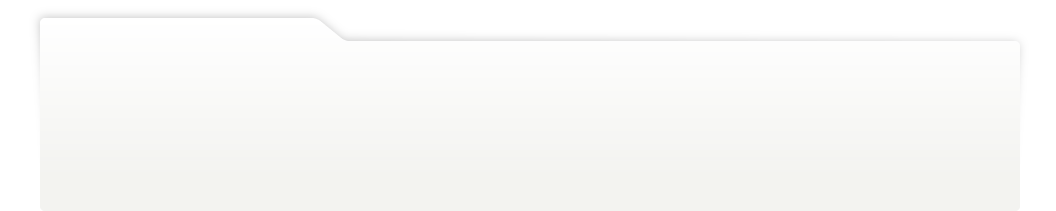
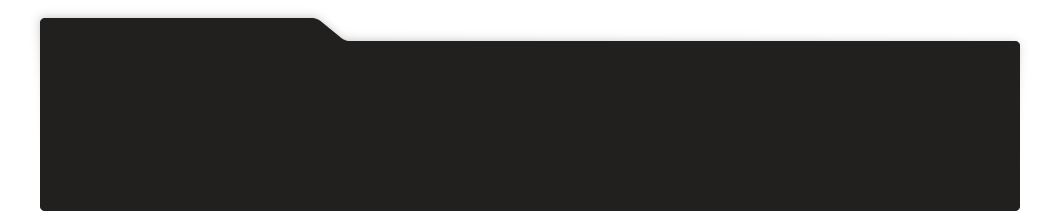
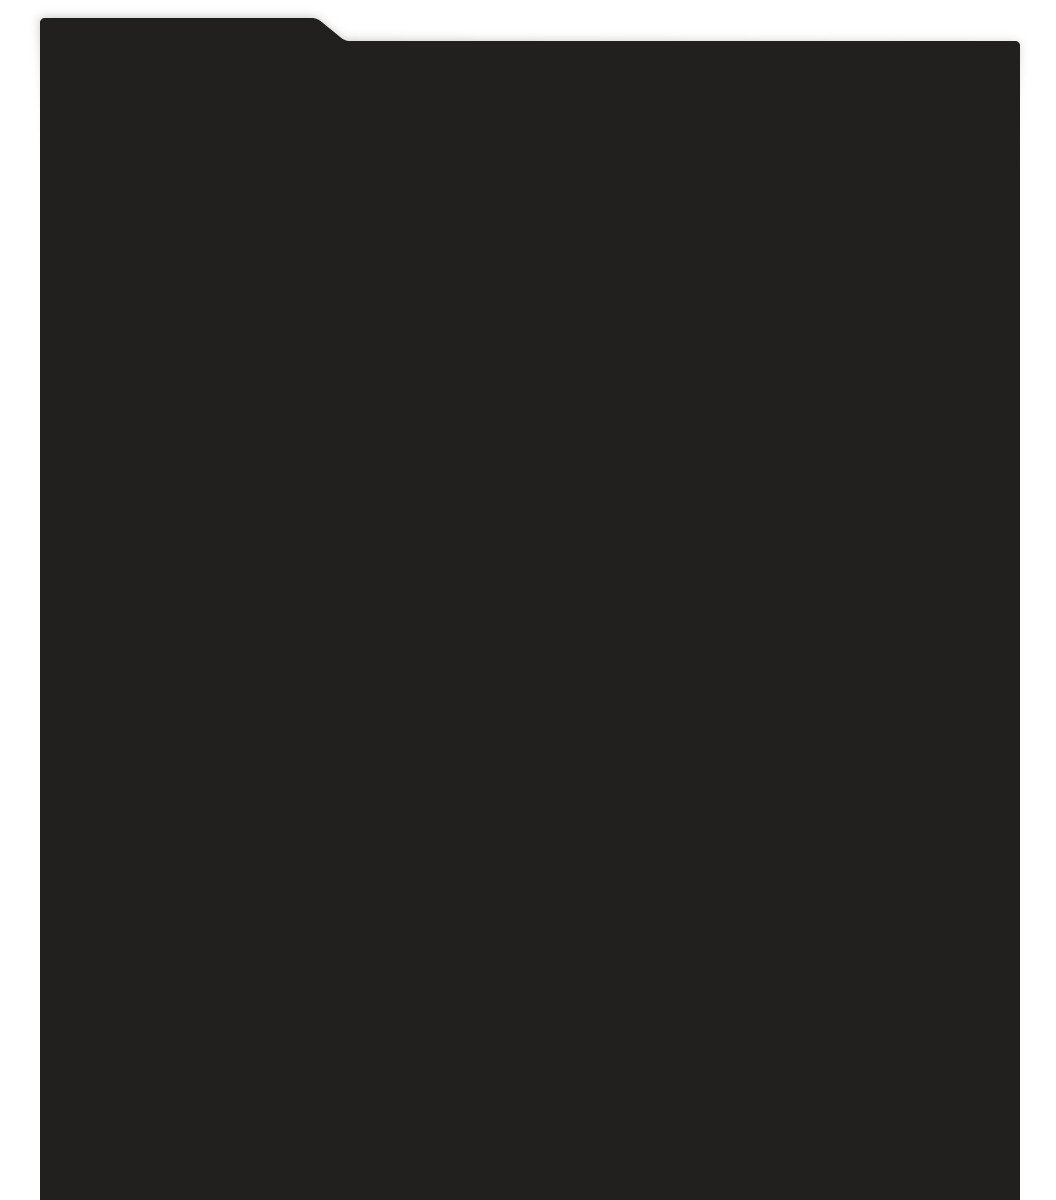
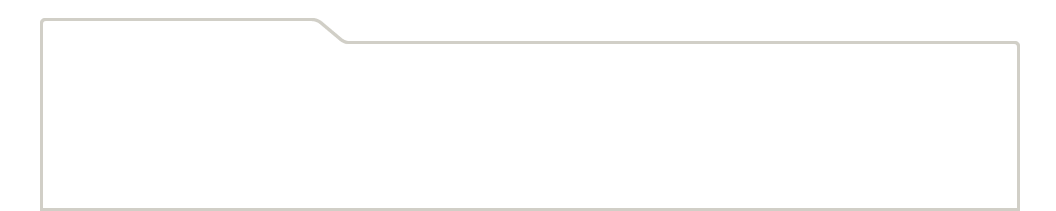
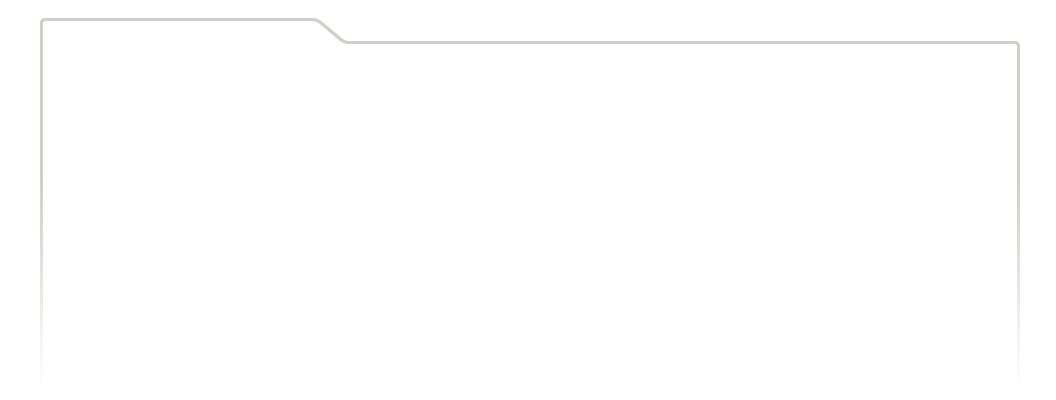
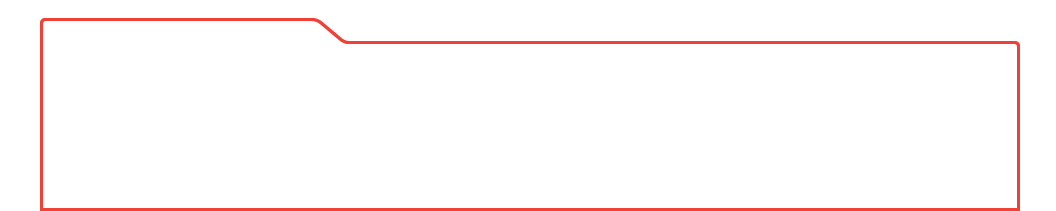
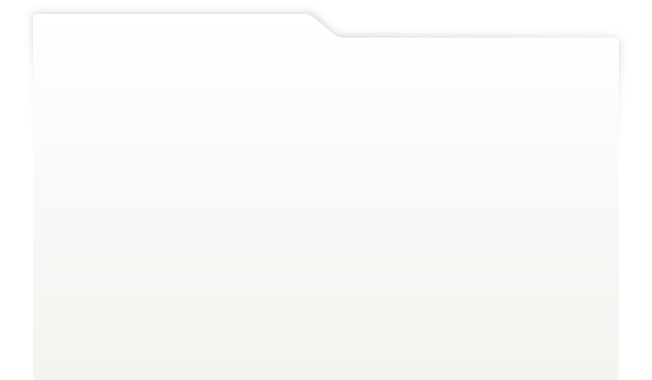
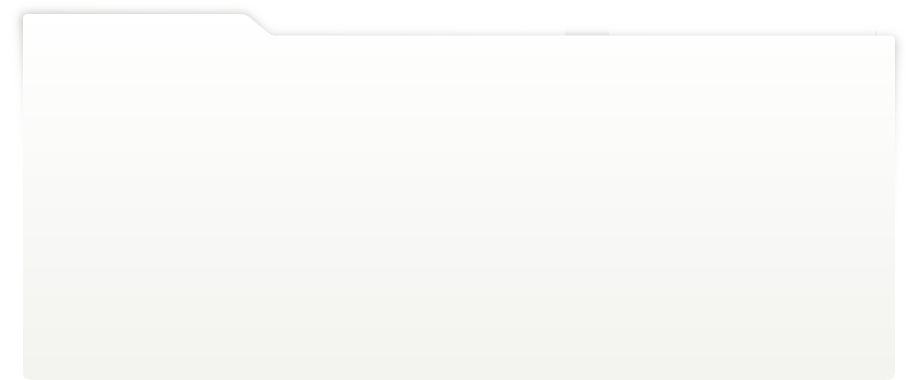
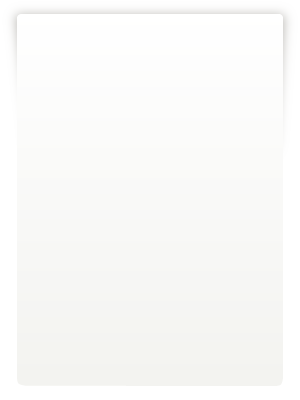
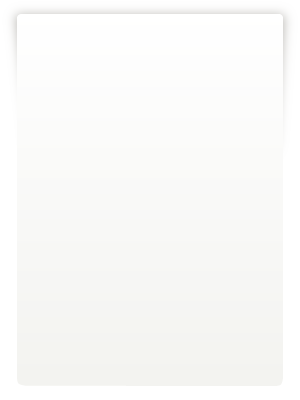
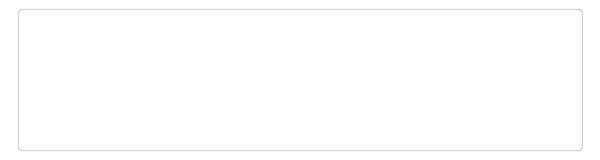
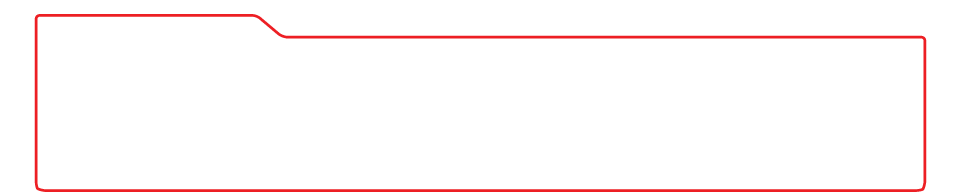
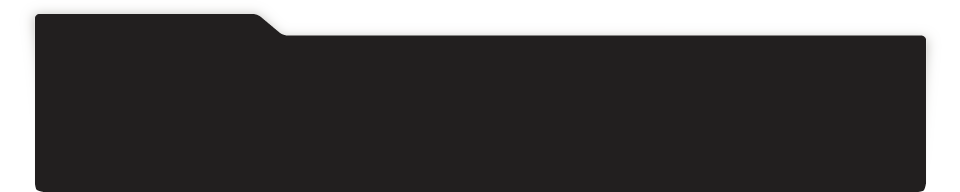
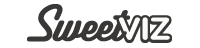
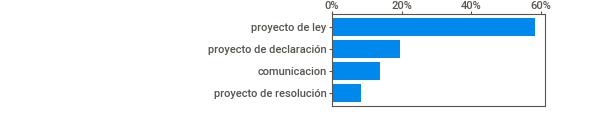
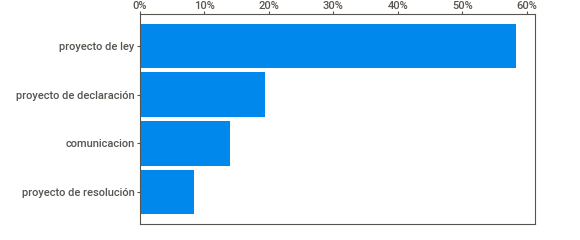
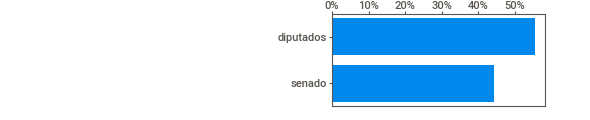
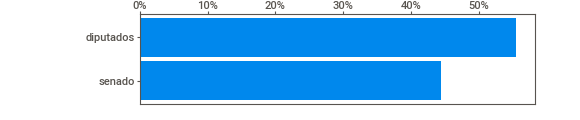
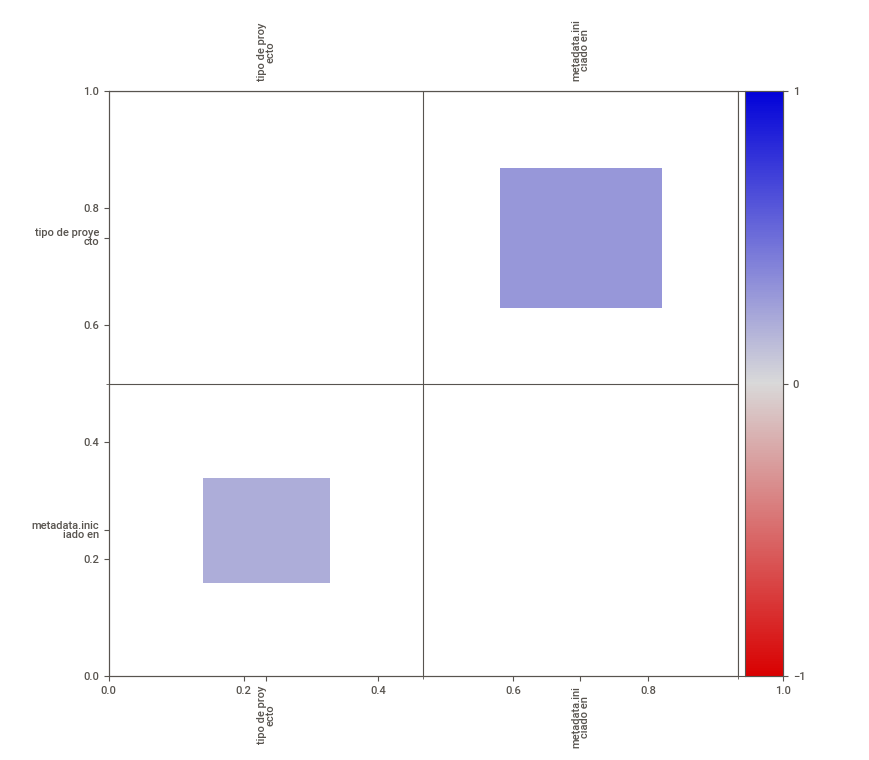
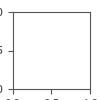

In [31]:
my_report.show_notebook(  w=None,
                h=None,
                scale=None,
                layout='widescreen',
                filepath=None,
                file_layout=None,
                file_scale=None)